1. Clustering Gerarchico 🌳
Il Clustering Gerarchico è un metodo di clustering che crea cluster misurando le differenze tra i dati. In particolare, il notebook si concentra sul tipo Agglomerative Clustering, che segue un approccio "dal basso verso l'alto" (bottom-up).

1.1 Come Funziona l'Agglomerative Clustering? 🔄
Inizio: Ogni punto dati è inizialmente considerato un cluster a sé stante.

Unione: I due cluster più vicini (quelli con la distanza più breve tra loro) vengono uniti per formare un cluster più grande.

Ripetizione: Questo passaggio viene ripetuto finché non si forma un unico grande cluster che contiene tutti i punti dati.

Per eseguire il clustering gerarchico, dobbiamo scegliere:

Metodo della Distanza: Come misurare la "vicinanza" tra i punti (es. Distanza Euclidea).

Metodo del Collegamento (Linkage Method): Come misurare la "vicinanza" tra i cluster (es. metodo di Ward, che tenta di minimizzare la varianza all'interno dei cluster).

In [1]:
#Si importano le librerie necessarie e si generano 
#300 punti dati casuali con 4 centri di cluster.
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.datasets import make_blobs

# Genera dati di esempio
X, _ = make_blobs(n_samples=300, centers=4, cluster_std=0.60, random_state=0)

In [10]:
#Ora trasformiamo i dati in un insieme di punti:
data = list(zip(X, _))
print(data)

[(array([0.83685684, 2.13635938]), np.int64(1)), (array([-1.4136581 ,  7.40962324]), np.int64(3)), (array([1.15521298, 5.09961887]), np.int64(0)), (array([-1.01861632,  7.81491465]), np.int64(3)), (array([1.27135141, 1.89254207]), np.int64(1)), (array([3.43761754, 0.26165417]), np.int64(1)), (array([-1.80822253,  1.59701749]), np.int64(2)), (array([1.41372442, 4.38117707]), np.int64(0)), (array([-0.20493217,  8.43209665]), np.int64(3)), (array([-0.71109961,  8.66043846]), np.int64(3)), (array([-1.71237268,  2.77780226]), np.int64(2)), (array([-2.67000792,  8.3538914 ]), np.int64(3)), (array([1.24258802, 4.50399192]), np.int64(0)), (array([-2.22783649,  6.89479938]), np.int64(3)), (array([ 1.45513831, -0.029199  ]), np.int64(1)), (array([0.45379179, 3.95647753]), np.int64(0)), (array([1.06923853, 4.53068484]), np.int64(0)), (array([2.56936589, 0.5070483 ]), np.int64(1)), (array([-1.0669061 ,  3.13165795]), np.int64(2)), (array([-1.07859101,  2.20451529]), np.int64(2)), (array([2.7150632

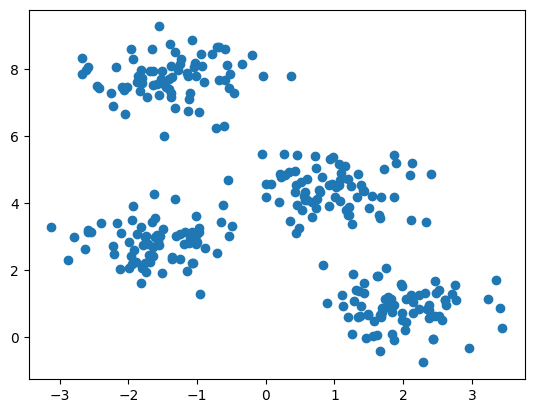

In [2]:
#Un semplice scatter plot mostra la distribuzione 
#originale dei punti.
plt.scatter(X[:,0], X[:,1])
plt.show()

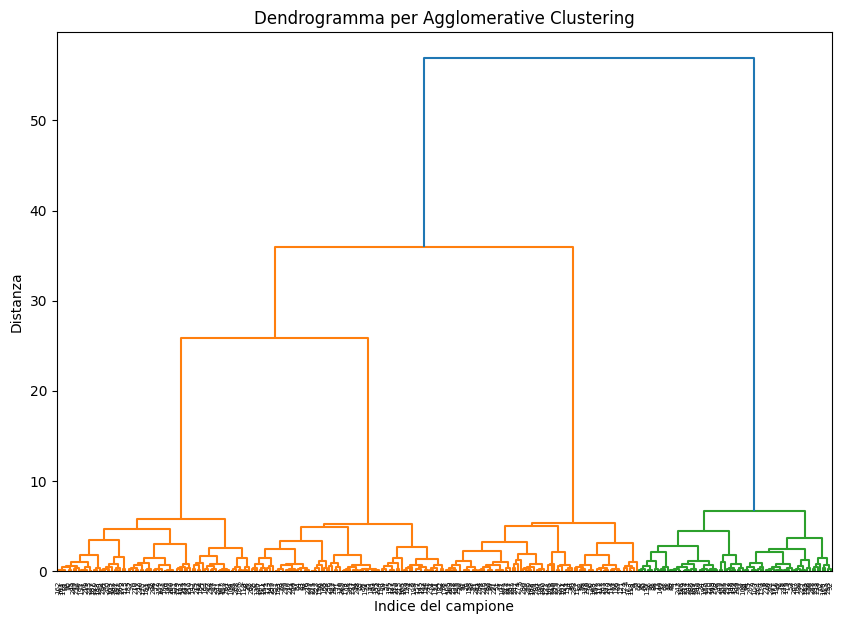

In [3]:
#Il dendrogramma mostra la gerarchia dei cluster. 
#Ogni unione di cluster è rappresentata da una 
#linea orizzontale.
# Calcola la matrice di linkage usando il metodo Ward e la distanza Euclidea
linked = linkage(X, method='ward')

# Crea il dendrogramma
plt.figure(figsize=(10, 7))
dendrogram(linked, orientation='top', distance_sort='descending', show_leaf_counts=True)
plt.title('Dendrogramma per Agglomerative Clustering')
plt.xlabel('Indice del campione')
plt.ylabel('Distanza')
plt.show()

In [4]:
#Si crea un'istanza di AgglomerativeClustering 
#specificando il numero di cluster desiderato 
# Esegue il clustering Agglomerativo con 4 cluster
cluster = AgglomerativeClustering(n_clusters=4, metric='euclidean', linkage='ward')
cluster_labels = cluster.fit_predict(X)
print(cluster_labels)

[2 0 1 0 2 2 3 1 0 0 3 0 1 0 2 1 1 2 3 3 2 2 1 3 3 1 2 1 3 1 0 0 1 0 0 0 0
 0 3 2 1 3 1 1 3 3 0 3 0 2 3 2 0 2 2 3 0 3 0 2 0 1 0 3 3 3 0 2 0 3 1 3 0 3
 3 0 3 1 2 0 2 1 2 2 0 1 2 1 0 0 1 2 0 3 3 1 2 2 1 3 0 2 0 2 1 2 2 1 0 1 3
 3 2 0 2 1 0 2 2 1 3 2 3 2 2 2 2 3 2 3 0 3 3 2 0 3 3 0 1 0 0 3 1 3 1 3 0 1
 0 0 0 1 0 1 2 3 0 3 2 1 0 1 1 2 1 3 3 1 2 1 1 0 2 1 3 0 2 2 1 3 2 1 3 3 1
 1 1 1 2 0 1 3 1 1 3 3 3 1 3 0 1 3 2 3 1 0 3 0 1 0 1 3 1 1 0 3 3 2 2 1 0 2
 2 3 2 3 1 0 0 1 1 0 1 2 3 1 2 3 0 3 2 1 2 0 0 0 0 3 3 0 1 3 2 1 3 3 3 2 2
 0 1 1 3 2 0 3 1 0 1 2 2 3 3 1 2 2 2 1 0 0 2 2 1 2 2 2 0 3 0 1 2 2 0 0 0 2
 2 1 0 3]


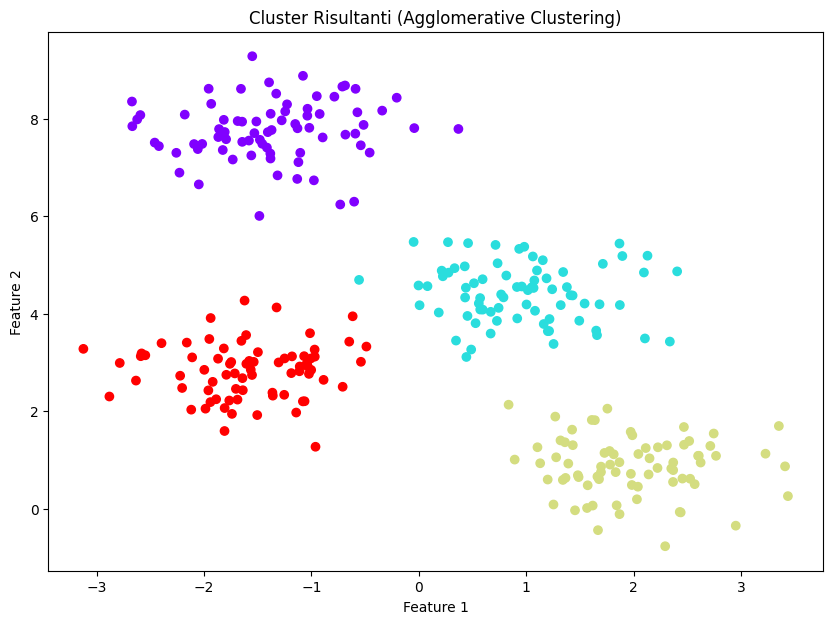

In [5]:
#I punti dati vengono colorati in base ai 
#cluster assegnati per visualizzare la separazione.
plt.figure(figsize=(10, 7))
plt.scatter(X[:,0], X[:,1], c=cluster_labels, cmap='rainbow')
plt.title('Cluster Risultanti (Agglomerative Clustering)')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()